In [1]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from tqdm import tqdm

In [2]:
## if some package is broken
# !pip uninstall -y matplotlib
# !pip install --no-cache-dir --upgrade matplotlib

# Домашнее задание #4 [10 баллов]

В этом домашнем задании мы предлагаем вам реализовать алгоритм LinUCB --- алгоритм, который решает задачу Contextual Bandits (бандиты с контекстом). Этот алгоритм придумала команда Yahoo research для оптимизации системы рекомендации новостей на главной. [Ссылка на оригинальную статью
](https://arxiv.org/pdf/1003.0146.pdf)


## Подготовка данных

Начнем с данных. В этом задании вы будете работать с упрощенным датасетом рекоммендаций новостей. Этот датасет состоит из $t = 10,000$ наблюдение. Каждое наблюдение характеризуется 102 переменными:
- `ActualAction` $ \in \{1, 2, 3, \ldots, 10\}$. Индекс новости, которая была действительно показана пользователю в эксперименте
- `Reward` $ \in \{0, 1\}$. Награда, которая равна 1 если пользователь кликнул новость и 0 иначе
- `F1, F2, ..., F100` Контекст, описывающий пользователя

Код ниже загружает датасет в Google Colab.

In [3]:
# Не меняйте этот код

# # Скачаем данные в локальную директорию, с которой можно работать прямо из Colab
# !gdown '1e7syyRL7kd_M-6Uc-M31HFIwV8gpuTr5'

"gdown" не является внутренней или внешней
командой, исполняемой программой или пакетным файлом. - I have to change the code

In [4]:
# # Не меняйте этот код

# df = pd.read_csv('/content/hw4_data.txt', header=None, index_col=False, sep=' ',
#                  names=["ActualAction", "Reward"] + [f"F{i}" for i in range(1, 101)])

Датасет, с которым вы работаете в этом задании был собран в режиме **random policy**: каждому пользователю показывалась случайная новость $a \in \{1, 2, 3, \ldots, 10 \}$.

Посмотрим на частоту выбора каждого действия и на общую долю кликов.

In [5]:
data = pd.read_csv("C:/Users/Popov/Documents/Studies/NES_studies/Python/AI/HA/HA4/hw4_data_exported.csv")

Text(0.5, 1.0, 'Доля кликов составляет 10%')

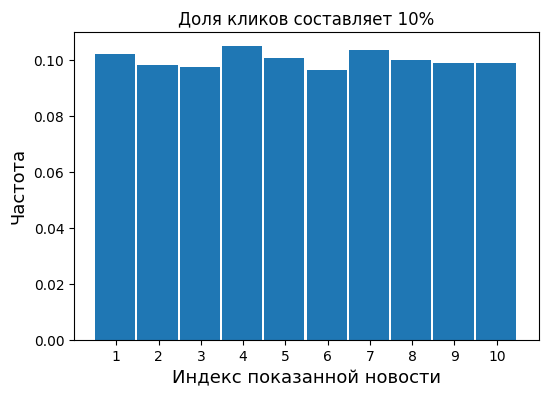

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.hist(data["ActualAction"], width=0.95, bins=[0.5 + x for x in range(11)],
        align='mid', density=True)
_ = ax.set_xticks([x for x in range(1, 11)])
_ = ax.set_xlabel("Индекс показанной новости", fontsize=13)
_ = ax.set_ylabel("Частота", fontsize=13)
ax.set_title(f"Доля кликов составляет {round(100 * np.mean(data['Reward']))}%")

## Идея задания

В этой работе мы исследуем два алгоритма: UCB-1 (разминка) и LinUCB (основное задание).

**Наша задача** Просимулировать обучение алгоритма в *online-режиме* (в порядке прихода пользователей), используя *offline-данные* (мы не знаем, что было бы, если бы для пользователя $t$ мы сделали другое предсказание).

**Наша метрика**  Click Trough Rate (CTR), то есть доля пользователей, которые кликнули на предложенную новость. Например, CTR случайного правила равен 10% (см. график выше).

**Подход к предсказанию**  Для предсказания новости на шаге $t$ алгоритмы будут использовать всю имеющуюся информацию (все данные из раундов $1, \ldots, t-1$).

**Подход к оценке алгоритма**  Для оценки CTR на момент $t$ мы будем использовать все раунды от 1 до $t$ в которых предсказания алгоритма совпадали с фактически показанными новостями. Введем некоторые обозначения:
- $a_t^*$ -- фактическая новость, показанная в раунде $t$
- $r_t$ -- фактический reward в раунде $t$
- $\hat{a}_t$ -- новость, которую наш алгоритм показал бы в раунде $t$

Тогда для любого раунда $t$ текущий CTR нашего алгоритма подсчитывается следующим образом:
$$\text{CTR}_t = \frac{\sum\limits_{i=1}^t r_t \times \mathbb{I} [a_t^* = \hat{a}_t]}{\sum\limits_{i=1}^t \mathbb{I} [a_t^* = \hat{a}_t]} $$


## Разминка. UCB-1 [4 балла]

Начнем с простого: алгоритма UCB-1.

**Алгоритм UCB-1**

Для начала попробуем использовать алгоритм UCB-1, который игнорирует контексты, то есть считает, что награда в раунде $t$ зависит только от выбранного действия, но не от контекста:
$$r_t \sim \mathcal{P}(a_t).$$

**Псевдокод алгоритма**

Параметр алгоритма: $\alpha$

Шаг 1. Устанавливаем Upper Confidence Bound (UCB) каждой новости в бесконечность

Шаг 2. Для каждого раунда от 1 до T:

- A. Выбираем новость $\hat{a}$ с наибольшей UCB (в случае ничьей выбираем случайно)

- B. Наблюдаем фактически показанную новость $a^*$ и фактический reward $r$

- С. Обновляем UCB новости $a^*$ (так как информацию мы получили по ней):
$$\text{UCB}' = \bar{r_t}(a^*) + \alpha \sqrt{\frac{1}{n_t(a^*)}}$$ Здесь $\bar{r_i}(a^{\ast})$ это CTR новости $a^{\ast}$ на момент $t$, а $n_t(a^*)$ это количество показов новости $a^{\ast}$ на момент $t$

- D. Подсчитываем $\text{CTR}_t$ для нашего алгоритма


**<font color='orange'>Задание</font>**

1. Реализуйте алгоритм UCB-1

2. Обучите алгоритм UCB-1 на наших данных с разными параметрами $\alpha$. Постройте графики $\text{CTR}_t$ для разных параметров на одном рисунке

3. Сравните UCB-1 с случайным алгоритмом

4. Напишите развернутый комментарий, объясняющий пункты 2 и 3. В чем смысла параметра $\alpha$?


Task 1

In [7]:
T = len(data)  # number of rounds (e.g., 10000)
K = 10         # number of news articles

# set a list of alpha parameters for experiments
alpha_list = [0.1, 0.5, 1.0, 2.0]
results = {}  # dictionary to store CTR history for each alpha

for alpha in alpha_list:
    # initialize: for each article, store count and total reward
    n = np.zeros(K)           # a: count of updates for each article
    sum_rewards = np.zeros(K)   # b: total reward for each article
    
    # initially, set UCB for each article to infinity so every article is chosen at least once
    ucb_values = np.array([np.inf] * K)
    
    # variables for CTR evaluation
    num_matches = 0  # c: number of rounds where prediction matched the actual article
    cum_reward = 0   # d: cumulative reward in those rounds
    ctr_history = [] # e: list to store CTR history

    # iterate over all rounds
    for t in range(T):
        # choose the article with the highest UCB (articles are indexed 0..K-1; add 1 to match article ids)
        chosen_action = np.argmax(ucb_values) + 1
        
        # get actual action and reward for the current round
        actual_action = data.loc[t, 'ActualAction']
        reward = data.loc[t, 'Reward']
        
        # if our prediction matches the actual shown article
        if chosen_action == actual_action:
            num_matches += 1
            cum_reward += reward
            
            # update statistics for the chosen article
            idx = chosen_action - 1  # f: adjust index
            n[idx] += 1
            sum_rewards[idx] += reward
            avg_reward = sum_rewards[idx] / n[idx]
            
            # update the UCB for this article
            ucb_values[idx] = avg_reward + alpha * np.sqrt(1 / n[idx])
        
        # note: if prediction doesn't match, no update occurs (bandit feedback)

        # compute current CTR (only for rounds with matching actions)
        current_ctr = cum_reward / num_matches if num_matches > 0 else 0.0
        ctr_history.append(current_ctr)
    
    results[alpha] = ctr_history

Task 2

In [8]:
# simulate the random algorithm
num_matches_random = 0
cum_reward_random = 0
ctr_history_random = []

for t in range(T):
    # g: choose a random article between 1 and K
    random_action = np.random.randint(1, K+1)
    actual_action = data.loc[t, 'ActualAction']
    reward = data.loc[t, 'Reward']
    
    if random_action == actual_action:
        num_matches_random += 1
        cum_reward_random += reward
        
    current_ctr = cum_reward_random / num_matches_random if num_matches_random > 0 else 0.0
    ctr_history_random.append(current_ctr)


Task 3

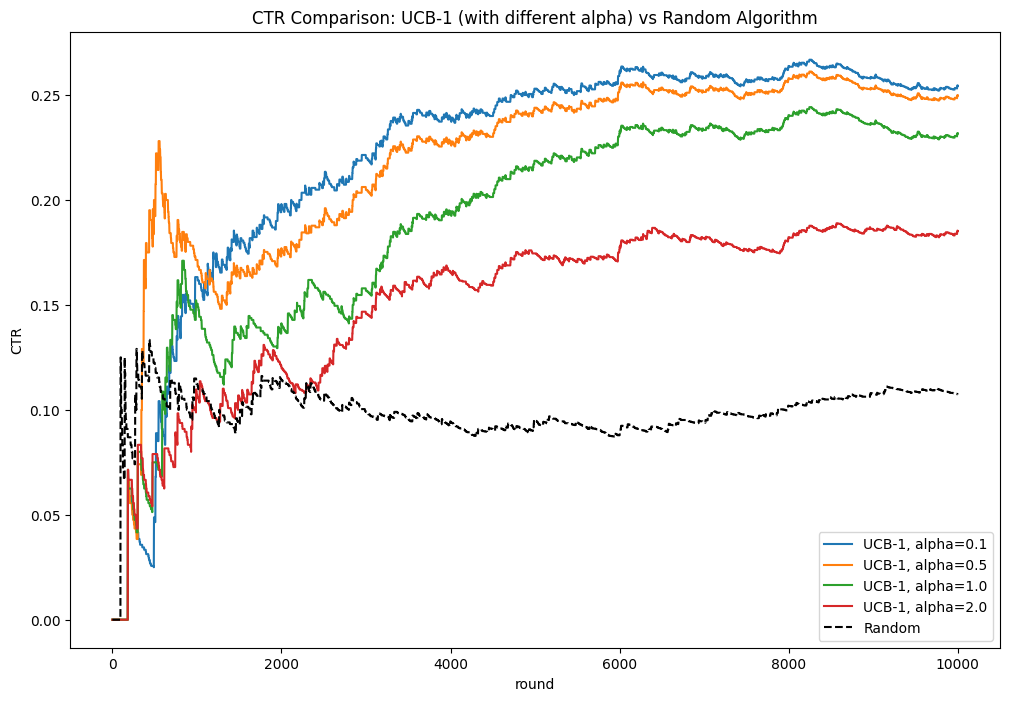

In [9]:
plt.figure(figsize=(12, 8))
# h: plot CTR for each alpha value
for alpha, ctr_history in results.items():
    plt.plot(ctr_history, label=f'UCB-1, alpha={alpha}')
# i: plot the random algorithm's CTR as a dashed black line
plt.plot(ctr_history_random, label='Random', linestyle='--', color='black')
plt.xlabel("round")
plt.ylabel("CTR")
plt.legend()
plt.title("CTR Comparison: UCB-1 (with different alpha) vs Random Algorithm")
plt.show()


Task 4.

- **1:** $\alpha$ sets how much extra bonus we give to options that haven’t been tried much.
- **2:** A higher $\alpha$ means we favor exploring articles that have been shown only a few times, even if their average reward is low.
- **3:** A lower $\alpha$ means we trust the current average reward more and stick to articles that are doing well.
- **4:** Picking the right $\alpha$ is important: too high, and might waste time exploring too many options (but it doesn't seem to be the case in our dataset); too low, and might miss out on better choices.
- **5:** The random algorithm is our baseline—it usually gets a steady, lower CTR (around 10%), while UCB-1 should do better by smartly balancing exploration and sticking with the winners.

## Основной алгоритм. LinUCB [6 баллов]

Теперь реализуем алгоритм, который учитывает контекст ---  LinUCB. Этот алгоритм построен на нескольких основных предположениях/идеях.

**Предположение/идея 1** Будем считатать, что матожидание награды для каждой пары (контекст $x$, действие $a$) определяется линейной моделью:
$$ \mathbb{E}[r | x, a] = x^T \theta_a, $$ где $x \in \mathbb{R}^d$ это вектор контекста,  а $\theta_a \in \mathbb{R}^d$ - неизвестный вектор, описывающий действие $a$ (для каждого действия он свой)

**Предположение/идея 2** Основная идея алгоритма --- попытаться оценить $\theta_a$ в процессе обучения. Для этого применяется линейная модель Ridge Regression.

Пусть в раундах $1, \ldots, t$ действие $a$ было фактически выбрано $m$ раз. Тогда запишем все соответствующие контексты в матрицу $D_a$ размера $m \times d$, а все соответствующие значения reward в вектор $c_a \in R^m$. Теперь применим Ridge Regression для оценки параметра $\theta_a$:
$$\hat{\theta}_a = (D_a^T D_a + I)^{-1} D_a^T c_a$$

**Предположение/идея 3** Аналогично алгоритму UCB-1, в каждом раунде будем выбирать действие с самой оптимистичной верхней границей на матожидание reward:
$$\hat{a}_t = \arg\max\limits_a \left[x^T \hat{\theta}_a + \alpha \sqrt{x^T (D_a^T D_a + I)^{-1} x} \right]$$ Здесь первое слагаемое это оценка мат. ожидания reward от действия $a$ (идея 1), а второе --- оценка дисперсии, следующая из свойств Ridge Regression.

**<font color='orange'>Задание</font>**

1. Реализуйте алгоритм LinUCB

2. Обучите алгоритм LinUCB на наших данных с разными параметрами $\alpha$. Постройте графики $\text{CTR}_t$ для разных параметров на одном рисунке

3. Сравните LinUCB с случайным алгоритмом и UCB-1

4. Напишите развернутый комментарий, объясняющий пункты 2 и 3. В чем смысла параметра $\alpha$?

**Подсказка** Для эффективной имплементации удобно ввести дополнительные матрицу и вектор:
$$A_a =  D_a^T D_a + I, \ b_a = D_a^T c_a.$$

- В таких обозначениях выражения, введенные выше, упрощаются:
$$\hat{\theta}_a = A_a^{-1} b_a $$
$$x^T \hat{\theta}_a + \alpha \sqrt{x^T (D_a^T D_a + I)^{-1} x} = x^T \hat{\theta}_a + \alpha \sqrt{x^T (A_a)^{-1} x} $$

- Новые объекты $A_a$ и $b_a$ легко обновлять после нового наблюдения $(x, a, r)$:
$$A_a' = A_a + x \cdot x^T, b_a' = b_a + r x$$

- Если действие $a$ еще не выбиралось, то матрица $A_a$ задается единичной матрицей, а вектор $b_a$ нулевым вектором

Task 1

In [10]:
# a: define context features (F1, F2, ..., F100)
feature_cols = [f'F{i}' for i in range(1, 101)]
d = len(feature_cols)  # a: context dimension

# -----------------------------------------------
# Task 1: Implement Optimized LinUCB with tqdm
# -----------------------------------------------
def run_linucb(alpha):
    """
    a: run linucb algorithm with given alpha using optimized linear solves
    """
    # a: initialize confidence matrices (A) and reward vectors (b) for each action
    A = {a: np.eye(d) for a in range(1, K+1)}   # each A_a starts as identity
    b = {a: np.zeros(d) for a in range(1, K+1)}   # each b_a starts as zeros

    num_matches = 0  # a: count rounds where chosen action equals actual action
    cum_reward = 0   # a: cumulative reward for these rounds
    ctr_history = []  # a: list to store CTR over rounds

    # a: loop over rounds with progress bar
    for t in tqdm(range(T), desc=f"LinUCB (alpha={alpha})"):
        # a: get current context vector x (shape: (d,))
        x = data.loc[t, feature_cols].values

        scores = np.zeros(K)  # a: initialize scores for each action
        # a: compute estimated reward and exploration bonus for each action
        for a in range(1, K+1):
            # a: compute theta_hat = A_a^{-1} * b_a using a linear solve
            theta_hat = np.linalg.solve(A[a], b[a])
            # a: compute v = A_a^{-1} * x using a linear solve (avoids explicit inversion)
            v = np.linalg.solve(A[a], x)
            bonus = alpha * np.sqrt(np.dot(x, v))  # a: exploration bonus
            scores[a-1] = np.dot(x, theta_hat) + bonus  # a: total score

        # a: select the action with the highest score
        chosen_action = np.argmax(scores) + 1  # a: adjust for 1-indexing
        actual_action = data.loc[t, 'ActualAction']  # a: true action from data
        reward = data.loc[t, 'Reward']  # a: observed reward

        # a: update only if our chosen action matches the actual action (bandit feedback)
        if chosen_action == actual_action:
            num_matches += 1
            cum_reward += reward
            # a: update A and b for chosen action incrementally
            A[chosen_action] += np.outer(x, x)
            b[chosen_action] += reward * x

        # a: compute current CTR using rounds with matching actions
        ctr = cum_reward / num_matches if num_matches > 0 else 0.0
        ctr_history.append(ctr)
        
    return ctr_history

Task 2

Graphs are plotted in the task 4 - just for convenience.

In [11]:
alphas = [0.1, 0.5, 1.0, 2.0]  # a: different exploration parameters to test
linucb_ctr_results = {}

# a: run linucb for each alpha and store CTR history
for alpha in alphas:
    linucb_ctr_results[alpha] = run_linucb(alpha)

LinUCB (alpha=2.0): 100%|██████████| 10000/10000 [00:16<00:00, 607.79it/s]


Task 3

In [12]:
def run_ucb1(alpha_ucb=1.0):
    """
    a: run context-free ucb-1 algorithm
    """
    counts = np.zeros(K)       # a: count updates for each action
    sum_rewards = np.zeros(K)  # a: cumulative reward for each action
    ucb_values = np.array([np.inf] * K)  # a: initialize ucb values to infinity

    num_matches = 0  # a: count rounds with matching actions
    cum_reward = 0   # a: cumulative reward from those rounds
    ctr_history = []  # a: list to store CTR over rounds

    for t in tqdm(range(T), desc="UCB-1"):
        chosen_action = np.argmax(ucb_values) + 1  # a: choose action with highest ucb
        actual_action = data.loc[t, 'ActualAction']  # a: get true action
        reward = data.loc[t, 'Reward']  # a: get observed reward

        if chosen_action == actual_action:
            num_matches += 1
            cum_reward += reward
            idx = chosen_action - 1  # a: convert to 0-index
            counts[idx] += 1
            sum_rewards[idx] += reward
            avg_reward = sum_rewards[idx] / counts[idx]
            ucb_values[idx] = avg_reward + alpha_ucb * np.sqrt(1 / counts[idx])
        
        ctr = cum_reward / num_matches if num_matches > 0 else 0.0
        ctr_history.append(ctr)
        
    return ctr_history

ucb1_ctr_history = run_ucb1(alpha_ucb=1.0)

def run_random():
    """
    a: run random algorithm that selects actions uniformly at random
    """
    num_matches = 0  # a: count rounds with matching actions
    cum_reward = 0   # a: cumulative reward for matching rounds
    ctr_history = []  # a: store CTR over rounds

    for t in tqdm(range(T), desc="Random"):
        random_action = np.random.randint(1, K+1)  # a: randomly select an action
        actual_action = data.loc[t, 'ActualAction']  # a: get true action
        reward = data.loc[t, 'Reward']  # a: get reward
        
        if random_action == actual_action:
            num_matches += 1
            cum_reward += reward
        
        ctr = cum_reward / num_matches if num_matches > 0 else 0.0
        ctr_history.append(ctr)
        
    return ctr_history

random_ctr_history = run_random()

Random: 100%|██████████| 10000/10000 [00:00<00:00, 68188.87it/s]


Task 4

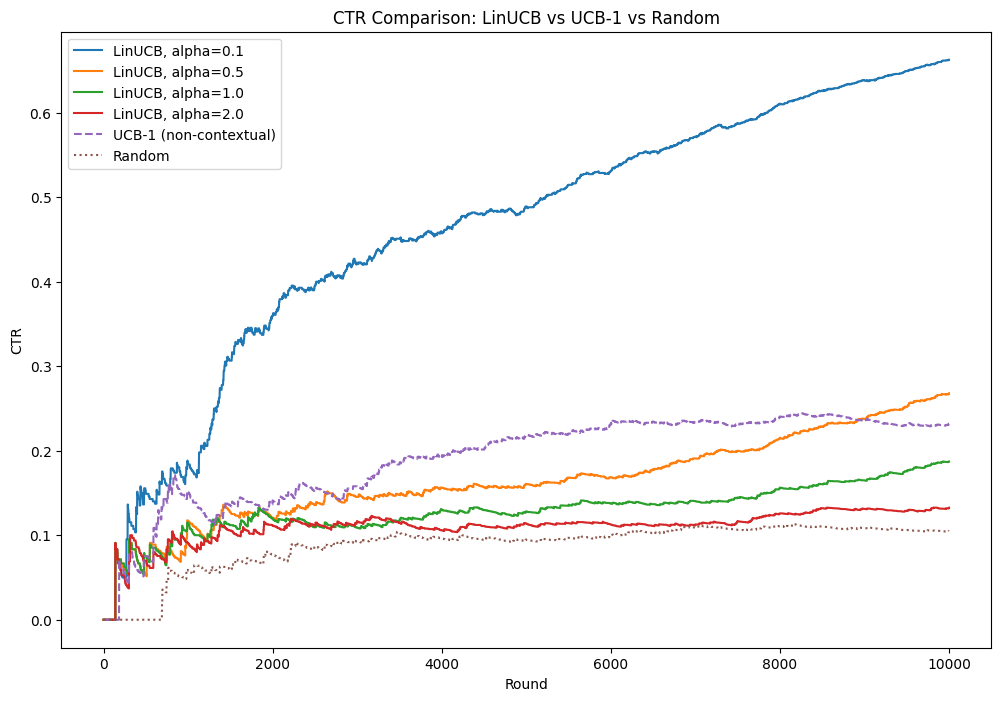

In [13]:
plt.figure(figsize=(12, 8))

# a: plot LinUCB CTR curves for each alpha value
for alpha, ctr_history in linucb_ctr_results.items():
    plt.plot(ctr_history, label=f'LinUCB, alpha={alpha}')

# a: plot UCB-1 (context-free) CTR curve
plt.plot(ucb1_ctr_history, label='UCB-1 (non-contextual)', linestyle='--')

# a: plot Random algorithm CTR curve
plt.plot(random_ctr_history, label='Random', linestyle=':')

plt.xlabel("Round") 
plt.ylabel("CTR")   
plt.title("CTR Comparison: LinUCB vs UCB-1 vs Random") 
plt.legend()         
plt.show()

- **1:** in linucb, context features help estimate expected rewards for each action.
- **2:** a higher $\alpha$ adds more exploration bonus, encouraging trying less-known actions.
- **3:** a lower $\alpha$ favors current reward estimates, reducing exploration.
- **4:** selecting the right $\alpha$ is key; too high may slow learning, too low may miss good options.
- **5:** compared to ucb-1 (which ignores context) and random selection, linucb should perform better when context is useful.
- **6:** just as before, lower $alpha$ seems better is our dataset. It might mean that heavy exploration isn’t needed for our dataset and that the best (or near-best) action is quickly found with a smaller exploration bonus ($alpha$)